# Fixed Effects

**Author:** Alejandro Orellana

**Date:** Janurary 14, 2026

**Data Source:** Chicago Energy Benchmarking Dataset (2014-2023) - City of Chicago Open Data Portal  

## Section 1: Loading Data

In [1]:
from utils.data_utils import load_data
from utils.plot_utils import plot_model_coefficients
from utils.stats_utils import (
    fixed_effects_analysis,
    prepare_analysis,
    prepared_dataframe,
)

panel_data = prepared_dataframe(load_data())
target_col = "Weather Normalized Site EUI (kBtu/sq ft)"
rating_col = "Chicago Energy Rating"
analysis_df = prepare_analysis(panel_data, target_col, rating_col)
analysis_df.head()

2026-01-17 21:53:41,404 [INFO] ✅ COVID Impact Category assignment (with 'Other' group) complete.
2026-01-17 21:53:41,407 [INFO] Category counts:
COVID Impact Category
Other                    985
Permanent               2370
Stable/Increased       10171
Temporary/Rebounded     5378


----------------------------------------
DATA ANALYSIS PREP SUMMARY
----------------------------------------
Initial Total Rows:        18904
Initial Unique Buildings:  2363
----------------------------------------
Rows with Future Change:   12000
Unique Buildings Retained: 2352
Unique Buildings Lost: 11
----------------------------------------


,Data Year,ID,Property Name,Address,ZIP Code,Community Area,Primary Property Type,Gross Floor Area - Buildings (sq ft),Year Built,# of Buildings,...,Water Use (kGal),Row_ID,COVID Impact Category,Current_EUI,Next_Year_EUI,Future_Change_Raw,Future_Change,Rating_Numeric,Rating_Cat,Post_Policy
11603,2016,100001,presence smemc st elizabeth campus,1431 North Claremont Ave,60622,west town,hospital,309056.0,1928.0,1.0,...,NaN,nan,Other,194.6,186.9,-7.7,-7.7,NaN,None,0
2543,2017,100001,presence smemc st elizabeth campus,1431 North Claremont Ave,60622,west town,hospital,309056.0,1928.0,1.0,...,NaN,nan,Other,186.9,186.5,-0.4,-0.4,NaN,None,0
28282,2018,100001,presence smemc st elizabeth campus,1431 North Claremont Ave,60622,west town,hospital,309056.0,1928.0,1.0,...,67.0,nan,Other,186.5,NaN,NaN,NaN,NaN,None,0
20009,2019,100001,presence smemc st elizabeth campus,1431 N Claremont Ave,60622,west town,hospital,309056.0,1928.0,3.0,...,NaN,nan,Other,NaN,180.0,NaN,NaN,NaN,None,1
6268,2020,100001,presence smemc st elizabeth campus,1431 N Claremont Ave,60622,west town,hospital,505417.0,1928.0,3.0,...,NaN,nan,Other,180.0,175.3,-4.7,-4.7,NaN,None,1


In [2]:
fe_model = fixed_effects_analysis(analysis_df)


--- Model: Two-Way Fixed Effects (Building & Year) ---
Using Reference Category: 0.0
                            OLS Regression Results                            
Dep. Variable:          Future_Change   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     97.87
Date:                Sat, 17 Jan 2026   Prob (F-statistic):          1.96e-192
Time:                        21:53:41   Log-Likelihood:                -30314.
No. Observations:                7317   AIC:                         6.065e+04
Df Residuals:                    7304   BIC:                         6.074e+04
Df Model:                          12                                         
Covariance Type:              cluster                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
-------

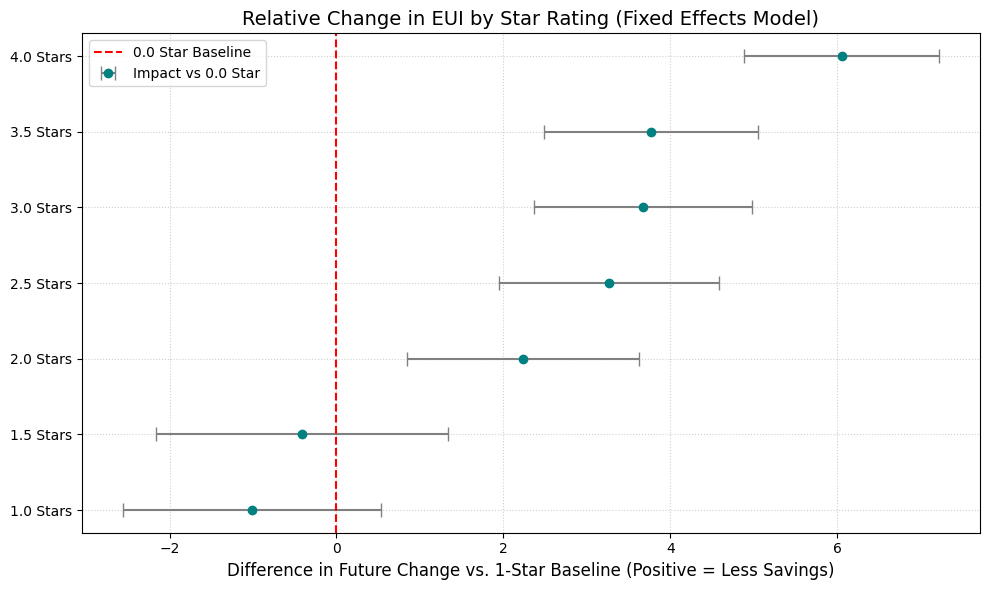

In [3]:
fig = plot_model_coefficients(fe_model)